# Tarea 5 — Clasificación de imágenes con redes convolucionales

**Procesamiento y Clasificación de Datos · MCD, FCFM-UANL**

## El experimento

La clase mostró dos formas de entrenar una CNN: **desde cero** y con **transfer learning**
(heredar los pesos de una red ya entrenada en ImageNet). La pregunta que este notebook responde
con números:

> ¿Cuánto vale heredar pesos de ImageNet cuando se tienen pocos datos?

Diseño — el mismo espíritu de la Tarea 3: dos enfoques, **mismas condiciones**:

| | Modelo A | Modelo B |
|---|---|---|
| Arquitectura | CNN desde cero (3 bloques conv) | MobileNetV2 congelada + capa densa |
| Pesos iniciales | aleatorios | ImageNet (congelados) |
| Datos | idénticos | idénticos |
| Épocas | 6 | 6 |
| Aumento de datos | idéntico | idéntico |

Se eligió MobileNetV2 (no VGG16 como en clase) porque está diseñada para ser ligera: ~2.3M de
parámetros contra 138M de VGG16. En una laptop sin GPU, esa diferencia es entrenar en minutos o
en horas.

## Datos

**tf_flowers**: 3,670 fotografías reales de flores en 5 clases (margarita, diente de león, rosa,
girasol, tulipán). Descarga automática (~220 MB) la primera vez.

Es deliberadamente chico: el punto del experimento es justamente el escenario de pocos datos,
donde el transfer learning debería brillar.

## 0. Verificar librerías

⚠️ **Nota para Mac con chip Apple (M1/M2/M3):** TensorFlow corre en CPU por defecto. Si quieres
acelerar con el GPU integrado, instala también `tensorflow-metal` (`%pip install tensorflow-metal`).
No es obligatorio — este notebook está dimensionado para correr en CPU en ~10–20 min.

In [18]:
import importlib.util

REQUERIDAS = ["tensorflow", "matplotlib", "pandas", "tabulate", "numpy"]

faltan = [p for p in REQUERIDAS if importlib.util.find_spec(p) is None]

if faltan:
    print("Instalando:", ", ".join(faltan))
    %pip install -q {" ".join(faltan)}
    print("\n>>> REINICIA el kernel (Restart) y corre de nuevo desde arriba <<<")
else:
    print("Todas las librerías están instaladas ✓")

Todas las librerías están instaladas ✓


In [19]:
#%pip install -q "numpy<2"

In [20]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # silenciar avisos informativos

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
SEMILLA = 42
IMG = 160          # lado de la imagen
LOTE = 32
EPOCAS = 6

keras.utils.set_random_seed(SEMILLA)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150,
                     "savefig.bbox": "tight", "font.size": 10})

print("TensorFlow", tf.__version__)
print("Dispositivos:", [d.device_type for d in tf.config.list_physical_devices()])

TensorFlow 2.16.2
Dispositivos: ['CPU', 'GPU']


## 1. Descargar y cargar el dataset

`get_file` descarga y descomprime una sola vez; las corridas siguientes usan la copia en caché
(`~/.keras/datasets/`). La partición es 80% entrenar / 20% validar, con semilla fija.

In [21]:
URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
descarga = Path(keras.utils.get_file("flower_photos", origin=URL, untar=True))

# get_file a veces devuelve la carpeta padre; buscar dónde están las clases
ruta = descarga if (descarga / "roses").exists() else descarga / "flower_photos"
assert (ruta / "roses").exists(), f"No encuentro las clases en {ruta}"
print("Dataset en:", ruta)

train_ds = keras.utils.image_dataset_from_directory(
    ruta, validation_split=0.2, subset="training", seed=SEMILLA,
    image_size=(IMG, IMG), batch_size=LOTE)
val_ds = keras.utils.image_dataset_from_directory(
    ruta, validation_split=0.2, subset="validation", seed=SEMILLA,
    image_size=(IMG, IMG), batch_size=LOTE)

clases = train_ds.class_names
n_clases = len(clases)
assert n_clases == 5, f"Esperaba 5 clases, encontré {n_clases}: {clases}"
print("Clases:", clases)

Dataset en: /Users/fisamzavalahernandez/.keras/datasets/flower_photos/flower_photos
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Clases: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


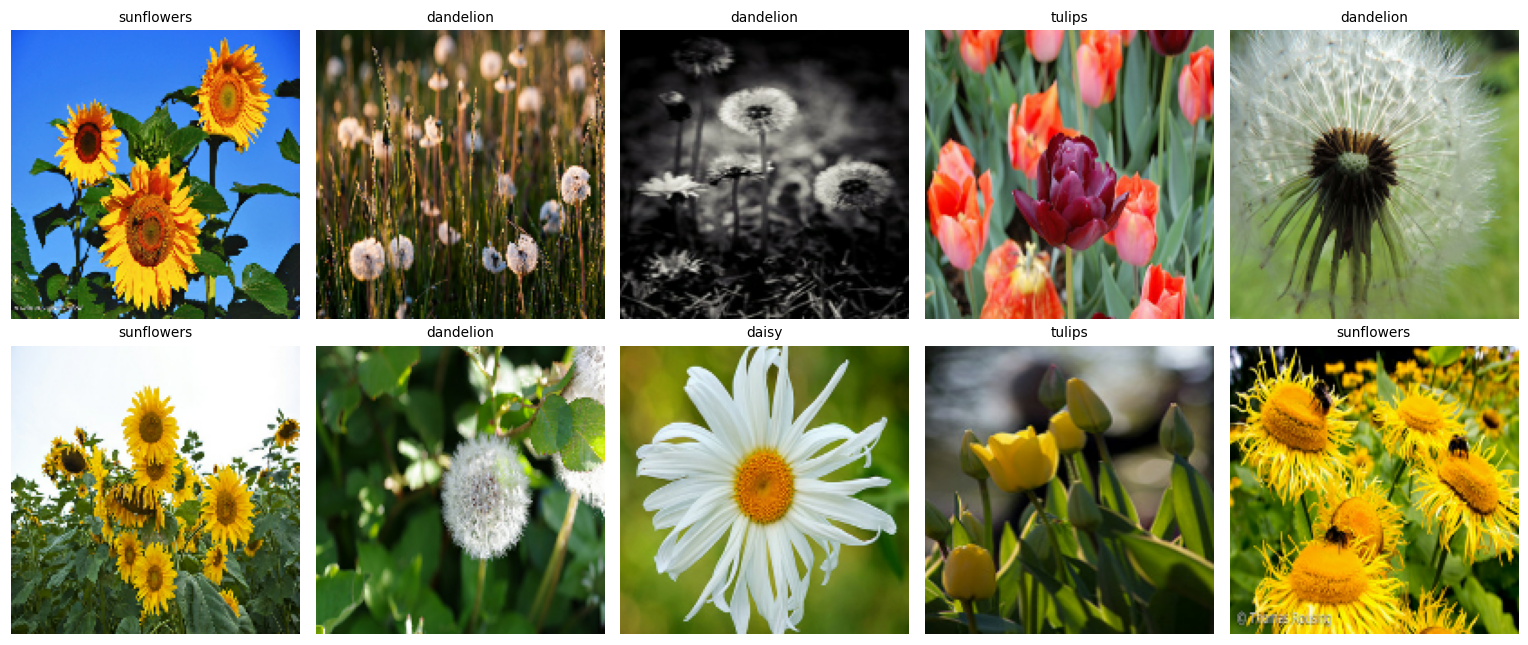

In [22]:
# muestra de imágenes
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for imagenes, etiquetas in train_ds.take(1):
    for ax, i in zip(axes.ravel(), range(10)):
        ax.imshow(imagenes[i].numpy().astype("uint8"))
        ax.set_title(clases[etiquetas[i]], fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.savefig(FIG / "1_muestra.png")
plt.show()

## 2. Preparación: caché, aumento de datos

- **`cache()` + `prefetch()`**: la primera época lee del disco; las siguientes, de memoria.
- **Aumento de datos**: volteos horizontales y rotaciones leves. Con solo ~600 fotos por clase,
  inventar variantes plausibles combate el sobreajuste. Se aplica *dentro* del modelo, así que
  solo actúa durante el entrenamiento, no en validación.

In [23]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEMILLA).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

aumento = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
], name="aumento")

## 3. Modelo A — CNN desde cero

Tres bloques convolución→pooling, como en la clase, con dos decisiones modernas:
`GlobalAveragePooling` en lugar de `Flatten` (muchos menos parámetros, menos sobreajuste) y
`Dropout` antes de la capa final.

In [24]:
def cnn_desde_cero():
    return keras.Sequential([
        layers.Input((IMG, IMG, 3)),
        aumento,
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(n_clases, activation="softmax"),
    ], name="cnn_desde_cero")


modelo_a = cnn_desde_cero()
modelo_a.summary()

Model: "cnn_desde_cero"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aumento (Sequential)            │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,893 (366.77 KB)

 Trainable params: 93,893 (366.77 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Modelo B — Transfer learning con MobileNetV2

La base viene entrenada en ImageNet (1.4 millones de imágenes, 1000 clases) y se **congela**: sus
filtros ya saben ver bordes, texturas y formas; solo se entrena la capa final que mapea esas
características a nuestras 5 flores.

Detalle importante: MobileNetV2 espera pixeles en [-1, 1], no en [0, 255]. El `Rescaling` de aquí
es distinto al del modelo A por esa razón.

In [25]:
def transfer_mobilenet():
    base = keras.applications.MobileNetV2(
        input_shape=(IMG, IMG, 3), include_top=False, weights="imagenet")
    base.trainable = False   # congelar: solo se entrena la cabeza

    return keras.Sequential([
        layers.Input((IMG, IMG, 3)),
        aumento,
        layers.Rescaling(1.0 / 127.5, offset=-1),   # [0,255] -> [-1,1]
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(n_clases, activation="softmax"),
    ], name="transfer_mobilenetv2")


modelo_b = transfer_mobilenet()
entrenables_b = np.sum([np.prod(v.shape) for v in modelo_b.trainable_weights])
print(f"Parámetros totales: {modelo_b.count_params():,}")
print(f"Parámetros ENTRENABLES: {int(entrenables_b):,}  (la base está congelada)")

Parámetros totales: 2,264,389
Parámetros ENTRENABLES: 6,405  (la base está congelada)


## 5. Entrenar ambos, mismas condiciones

Mismo optimizador, mismas épocas, mismos datos. Se cronometra cada uno.

*(En CPU esto es la parte lenta: ~10–20 min en total. La primera época de cada modelo es la más
tarda por la construcción del caché.)*

In [26]:
historias, tiempos = {}, {}

for nombre, modelo in [("CNN desde cero", modelo_a), ("Transfer MobileNetV2", modelo_b)]:
    modelo.compile(optimizer="adam",
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
    print(f"\n=== {nombre} ===")
    t0 = time.time()
    historias[nombre] = modelo.fit(train_ds, validation_data=val_ds,
                                   epochs=EPOCAS, verbose=1)
    tiempos[nombre] = time.time() - t0
    print(f"Tiempo: {tiempos[nombre]:.0f} s")


=== CNN desde cero ===
Epoch 1/6


92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.3753 - loss: 1.3773 - val_accuracy: 0.4183 - val_loss: 1.2222
Epoch 2/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.4608 - loss: 1.2362 - val_accuracy: 0.4673 - val_loss: 1.1689
Epoch 3/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.5146 - loss: 1.1738 - val_accuracy: 0.5790 - val_loss: 1.0699
Epoch 4/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.5616 - loss: 1.1175 - val_accuracy: 0.6131 - val_loss: 1.0610
Epoch 5/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.5787 - loss: 1.0814 - val_accuracy: 0.5599 - val_loss: 1.0946
Epoch 6/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.5851 - loss: 1.0570 - val_accuracy: 0.5967 - val_loss: 1.0299
Tiempo: 49 s

=== Transfer MobileNetV2 ===
Epoch 1/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 188ms/step - accuracy: 0.6165 - loss: 1.0177 - val_accuracy: 0.8270 - val_loss: 0.5046
Epoch 2/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.8151 - loss: 0.51

## 6. Comparación

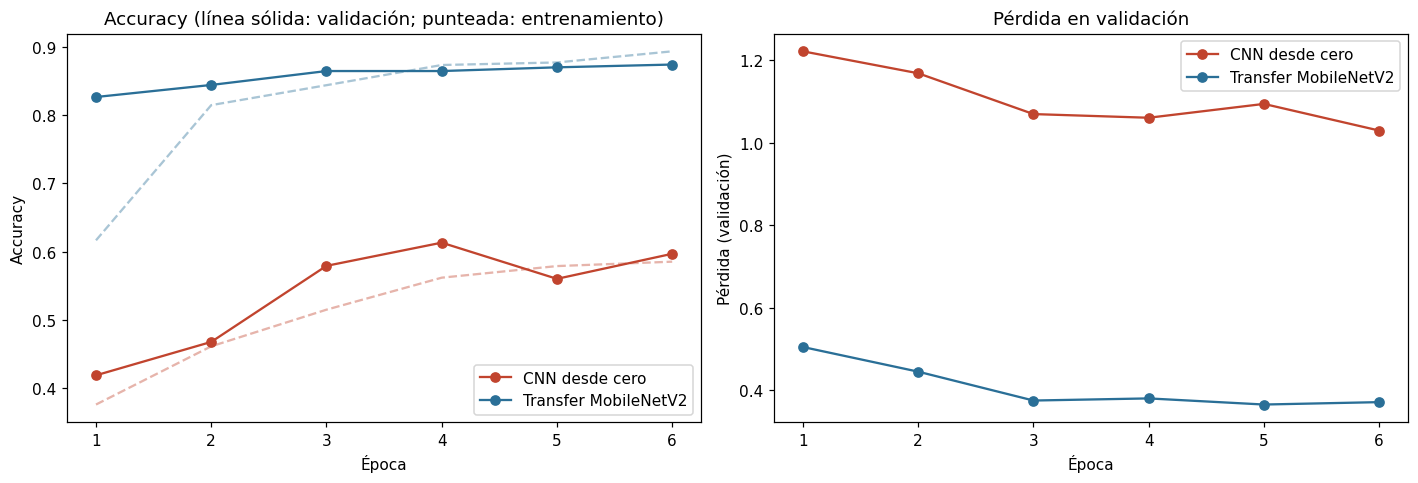

,Val accuracy final,Val accuracy época 1,Parámetros entrenables,Segundos de entrenamiento
CNN desde cero,0.596730,0.418256,93893.0,49.0
Transfer MobileNetV2,0.874659,0.826975,6405.0,65.0


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colores = {"CNN desde cero": "#c1442e", "Transfer MobileNetV2": "#2a6f97"}

for nombre, h in historias.items():
    ep = range(1, EPOCAS + 1)
    axes[0].plot(ep, h.history["val_accuracy"], "o-", label=nombre, color=colores[nombre])
    axes[0].plot(ep, h.history["accuracy"], "--", alpha=0.4, color=colores[nombre])
    axes[1].plot(ep, h.history["val_loss"], "o-", label=nombre, color=colores[nombre])

axes[0].set(xlabel="Época", ylabel="Accuracy", title="Accuracy (línea sólida: validación; punteada: entrenamiento)")
axes[1].set(xlabel="Época", ylabel="Pérdida (validación)", title="Pérdida en validación")
for ax in axes: ax.legend()
plt.tight_layout()
plt.savefig(FIG / "2_curvas.png")
plt.show()

resumen = pd.DataFrame({
    nombre: {
        "Val accuracy final": h.history["val_accuracy"][-1],
        "Val accuracy época 1": h.history["val_accuracy"][0],
        "Parámetros entrenables": int(np.sum([np.prod(v.shape) for v in
            (modelo_a if "cero" in nombre else modelo_b).trainable_weights])),
        "Segundos de entrenamiento": round(tiempos[nombre]),
    } for nombre, h in historias.items()
}).T
resumen

**Qué mirar en la tabla y las curvas:**

1. **La época 1 lo dice casi todo.** El transfer learning suele arrancar ya arriba del 70% —
   sus filtros llegaron sabiendo ver — mientras la CNN desde cero arranca cerca del azar (20%).
2. **La brecha final.** Con 6 épocas y ~3,000 fotos, la CNN desde cero no alcanza a la
   pre-entrenada. Podría acercarse con 50 épocas… o no: con tan pocos datos, su techo es más bajo.
3. **Parámetros entrenables.** El modelo B entrena ~6,500 parámetros; el A, ~93,000. El B aprende
   menos y rinde más, porque lo difícil ya venía aprendido.

## 7. ¿Dónde se equivoca el ganador?

Mejor modelo: Transfer MobileNetV2


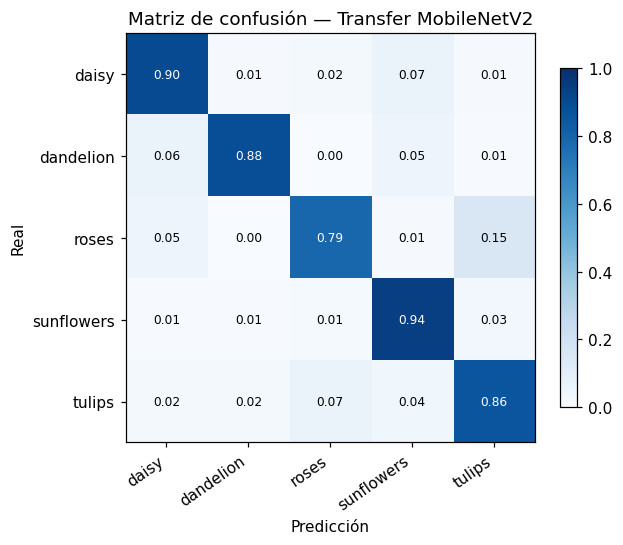

In [28]:
# predicciones del mejor modelo sobre validación
mejor_nombre = max(historias, key=lambda n: historias[n].history["val_accuracy"][-1])
mejor = modelo_a if "cero" in mejor_nombre else modelo_b
print("Mejor modelo:", mejor_nombre)

y_real, y_pred, imgs_mal = [], [], []
for imagenes, etiquetas in val_ds:
    p = mejor.predict(imagenes, verbose=0).argmax(axis=1)
    y_real.extend(etiquetas.numpy()); y_pred.extend(p)
    mal = np.where(p != etiquetas.numpy())[0]
    for i in mal[:2]:
        if len(imgs_mal) < 8:
            imgs_mal.append((imagenes[i].numpy().astype("uint8"),
                             clases[etiquetas[i]], clases[p[i]]))

y_real, y_pred = np.array(y_real), np.array(y_pred)

# matriz de confusión
cm = np.zeros((n_clases, n_clases), int)
for r, p in zip(y_real, y_pred): cm[r, p] += 1
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n_clases)); ax.set_xticklabels(clases, rotation=35, ha="right")
ax.set_yticks(range(n_clases)); ax.set_yticklabels(clases)
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión — {mejor_nombre}")
for i in range(n_clases):
    for j in range(n_clases):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm_norm[i,j] > 0.5 else "black", fontsize=8)
plt.colorbar(im, shrink=0.8)
plt.savefig(FIG / "3_confusion.png")
plt.show()

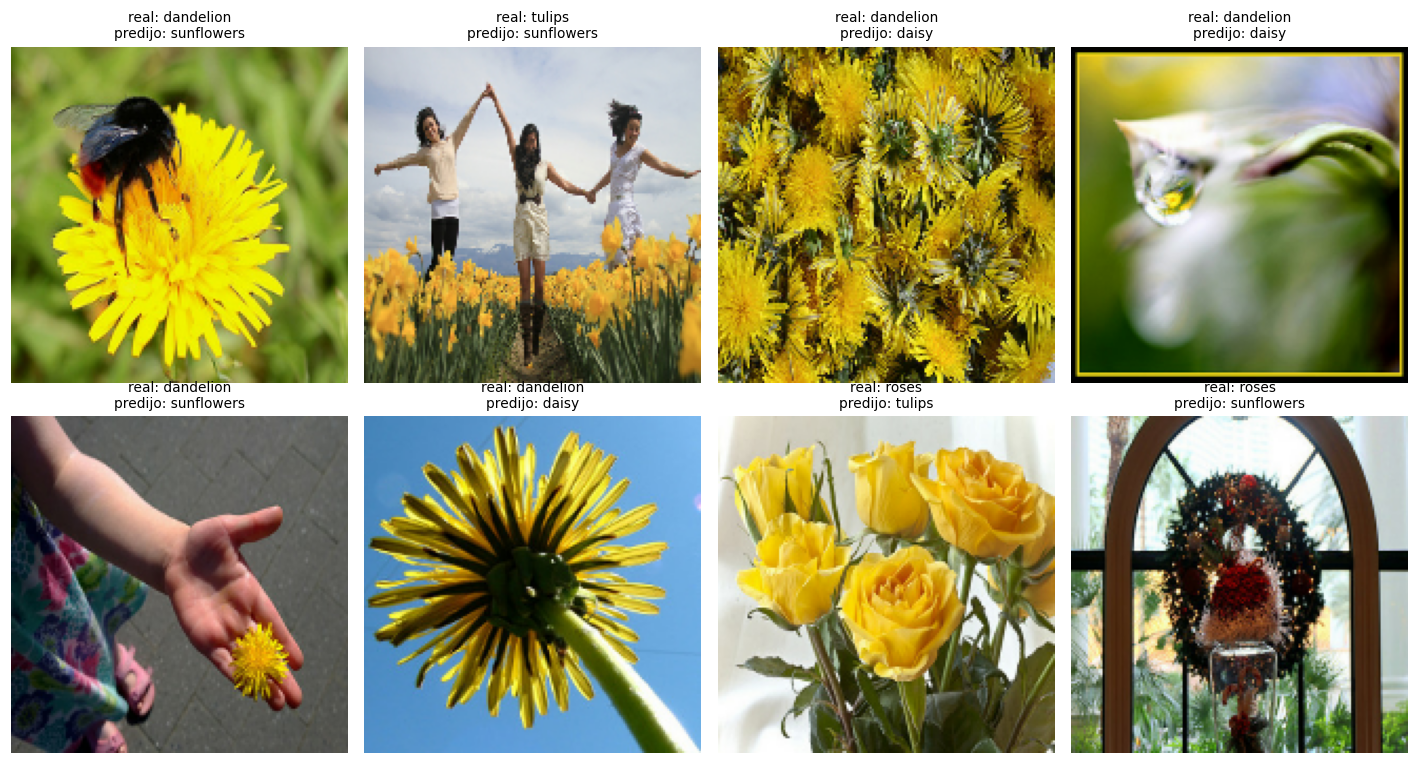

In [29]:
# ejemplos mal clasificados
if imgs_mal:
    fig, axes = plt.subplots(2, 4, figsize=(13, 7))
    for ax, (img, real, pred) in zip(axes.ravel(), imgs_mal):
        ax.imshow(img)
        ax.set_title(f"real: {real}\npredijo: {pred}", fontsize=9)
        ax.axis("off")
    for ax in axes.ravel()[len(imgs_mal):]: ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIG / "4_errores.png")
    plt.show()

## 8. Generar el reporte


In [30]:
acc_a = historias["CNN desde cero"].history["val_accuracy"]
acc_b = historias["Transfer MobileNetV2"].history["val_accuracy"]
acc_global = (y_real == y_pred).mean()

reporte = f"""# Tarea 5 — Clasificación de imágenes con CNNs

**Procesamiento y Clasificación de Datos · MCD, FCFM-UANL**

## Objetivo

Comparar, en condiciones idénticas, una CNN entrenada **desde cero** contra **transfer learning**
con MobileNetV2 pre-entrenada en ImageNet, para clasificar fotografías de flores en 5 clases.
La pregunta: ¿cuánto vale heredar pesos cuando hay pocos datos?

## Datos

**tf_flowers**: 3,670 fotografías, 5 clases ({", ".join(clases)}), partición 80/20 estratificada
por carpeta, semilla 42.

![Muestra](figuras/1_muestra.png)

## Diseño

Mismos datos, mismo aumento (volteo horizontal + rotación ±10%), mismo optimizador (Adam), mismas
{EPOCAS} épocas. Solo cambia el modelo:

| | CNN desde cero | Transfer MobileNetV2 |
|---|---|---|
| Pesos iniciales | aleatorios | ImageNet, congelados |
| Parámetros entrenables | {resumen.loc["CNN desde cero", "Parámetros entrenables"]:,} | {resumen.loc["Transfer MobileNetV2", "Parámetros entrenables"]:,} |

## Resultados

![Curvas](figuras/2_curvas.png)

| | Val. acc. época 1 | Val. acc. final | Tiempo (s) |
|---|---:|---:|---:|
| CNN desde cero | {acc_a[0]:.3f} | {acc_a[-1]:.3f} | {resumen.loc["CNN desde cero", "Segundos de entrenamiento"]} |
| Transfer MobileNetV2 | {acc_b[0]:.3f} | {acc_b[-1]:.3f} | {resumen.loc["Transfer MobileNetV2", "Segundos de entrenamiento"]} |

Dos observaciones:

1. **La época 1 cuenta la historia**: el transfer learning arranca en {acc_b[0]:.0%} — sus filtros
   llegaron sabiendo ver bordes, texturas y formas — mientras la red desde cero arranca en
   {acc_a[0]:.0%}, cerca del azar (20% con 5 clases).
2. **La brecha final es de {abs(acc_b[-1]-acc_a[-1]):.0%}**. Con ~600 fotos por clase, la red
   desde cero no tiene datos suficientes para descubrir lo que ImageNet ya le enseñó a la otra.

## Análisis de errores ({mejor_nombre}, acc. global {acc_global:.1%})

![Confusión](figuras/3_confusion.png)

![Errores](figuras/4_errores.png)

Las confusiones se concentran entre clases visualmente cercanas (rosas y tulipanes comparten
colores y fondos de jardín). Los ejemplos mal clasificados suelen ser fotos con la flor pequeña
en el encuadre, múltiples flores, o ángulos atípicos.

## Conclusiones

1. Con pocos datos, **el transfer learning no es una mejora incremental: es la diferencia entre
   funcionar y no funcionar bien** ({acc_b[-1]:.0%} vs {acc_a[-1]:.0%} en {EPOCAS} épocas).
2. El modelo pre-entrenado logra más entrenando **menos parámetros**
   ({resumen.loc["Transfer MobileNetV2", "Parámetros entrenables"]:,} vs
   {resumen.loc["CNN desde cero", "Parámetros entrenables"]:,}): lo difícil — ver — ya venía aprendido.
3. El costo computacional es comparable en CPU; MobileNetV2 está diseñada precisamente para eso.

## Limitaciones

- {EPOCAS} épocas favorecen al pre-entrenado; con muchas más, la CNN desde cero mejoraría, aunque
  con 3,670 fotos su techo probablemente sigue abajo.
- No se hizo *fine-tuning* (descongelar capas superiores de la base); es la extensión natural.
- Una sola semilla; con validación cruzada los números tendrían intervalos.

## Reproducir

Correr `Tarea5/cnn_flores.ipynb`. El dataset (~220 MB) y los pesos de ImageNet (~9 MB) se
descargan automáticamente la primera vez. Requiere `tensorflow`; en Mac con chip Apple,
`tensorflow-metal` acelera con el GPU integrado (opcional).

## Referencias

- Sandler, M. et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR.
- Deng, J. et al. (2009). *ImageNet: A Large-Scale Hierarchical Image Database*. CVPR.
- The TensorFlow Team. *Flowers dataset*.
"""

Path("README.md").write_text(reporte, encoding="utf-8")
print("README.md escrito ✓")

README.md escrito ✓
